<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Metropolis-Hastings</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm, uniform

---

In Bayesian inference, evaluating the posterior distribution $p(\theta\vert{}y) = \frac{p(y\vert{}\theta)p(\theta)}{p(y)}$ poses a fundamental computational challenge due to the intractability of the marginal likelihood $p(y) = \int p(y\vert{}\theta)p(\theta)d\theta$, particularly in high-dimensional or non-conjugate settings. Because this normalizing constant is generally unknown, standard sampling techniques such as inverse transform or accept-reject sampling cannot be applied. The Metropolis-Hastings (MH) algorithm circumvents this limitation by constructing a Markov chain to generate a set of posterior draws $\{\theta^{(1)}, \theta^{(2)}, \dots, \theta^{(M)}\}$ using exclusively the unnormalized numerator $p(y\vert{}\theta)p(\theta)$.

The algorithm itself is written out as follows:

$$
\begin{aligned}
\text{Given:}& \quad \nu^{(t)}; \quad t = 1, \dots, T \\[10pt]
\text{1. }& \text{Propose} \quad \nu^{new} \sim q(\cdot | \nu^{old}=\nu^{(t)})\\[5pt]
\text{2. }& \text{Accept} \quad 
\begin{array}{ll}
p(\nu^{(t+1)}=\nu^{new}) = \alpha(\nu^{new}, \nu^{old}) \\
p(\nu^{(t+1)}=\nu^{old}) = 1 - \alpha(\nu^{new}, \nu^{old})
\end{array}
\\
\end{aligned}\\[15pt]

\frac{f(\nu^{\text{new}})}{f(\nu^{\text{old}})} 
= \frac{\frac{p(y\vert{}\nu^{\text{new}})p(\nu^{\text{new}})}{p(y)}}{\frac{p(y\vert{}\nu^{\text{old}})p(\nu^{\text{old}})}{p(y)}} = \frac{p(y\vert{}\nu^{\text{new}})p(\nu^{\text{new}})}{p(y\vert{}\nu^{\text{old}})p(\nu^{\text{old}})} 
\qquad \longrightarrow \qquad
\alpha(\nu^{new}, \nu^{old}) 
= \min \left\{ \frac{f(\nu^{new})q(\nu^{old}|\nu^{new})}{f(\nu^{old})q(\nu^{new}|\nu^{old})}, 1 \right\} 

$$

---

In [14]:
np.random.seed(35)
x = np.linspace(-7, 7, 3000)

n_s = 1000
mu, sigma = 3.5, 1/2
data = np.random.normal(loc=mu, scale=sigma, size=n_s)


Visuals:

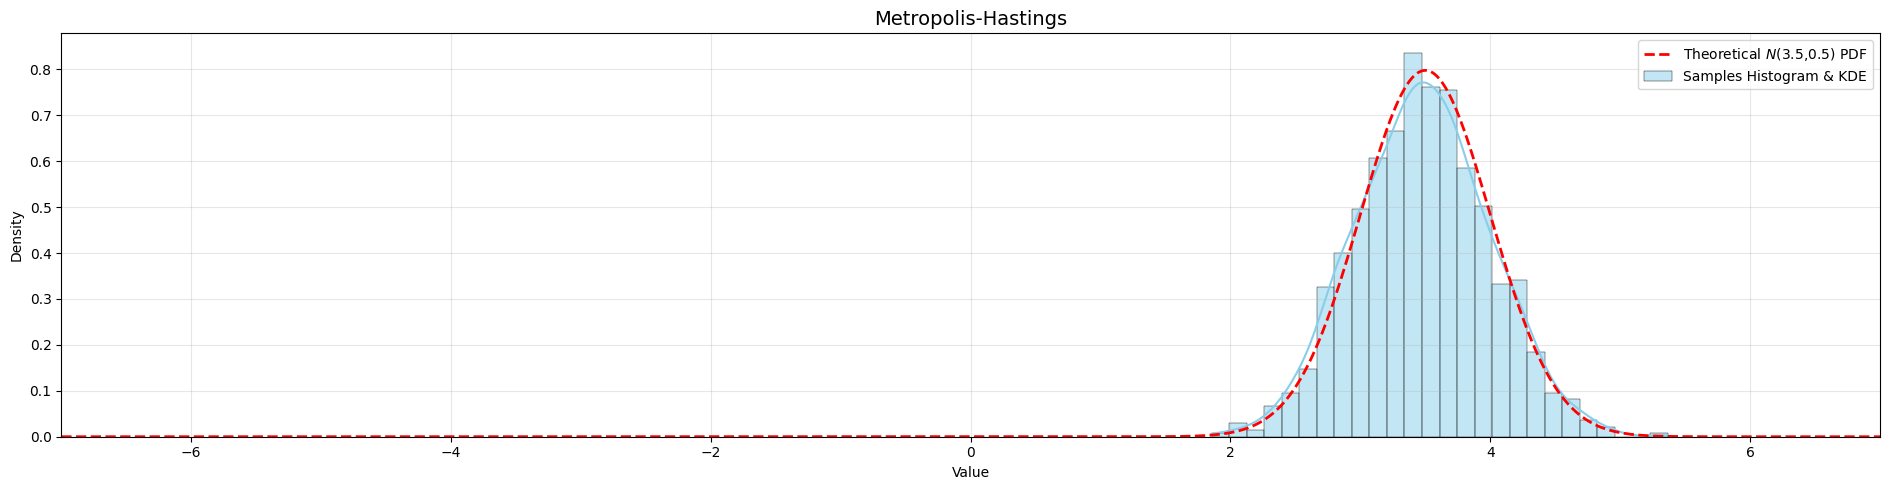

In [15]:
fig, ax = plt.subplots(figsize=(19, 5))

sns.histplot(
    data,
    kde=True,
    stat="density",
    color="skyblue",
    label="Samples Histogram & KDE",
    linewidth=0.3,
    ax=ax,
)

ax.plot(x, norm.pdf(x, mu, sigma), "r--", label=f"Theoretical $N$({mu},{sigma}) PDF", linewidth=2, zorder=2)

ax.set_xlim(min(x), max(x))

ax.set_title(f"Metropolis-Hastings", fontsize=14)
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig('Outputs/Metropolis-Hastings/function_plots.png')
plt.show()